Качество 10
Исходный: 406284 байт | Сжатый: 40745 байт | Восстановленный: 134234 байт | Степень: 9.97
Качество 20
Исходный: 406284 байт | Сжатый: 59624 байт | Восстановленный: 137692 байт | Степень: 6.81
Качество 30
Исходный: 406284 байт | Сжатый: 78011 байт | Восстановленный: 135292 байт | Степень: 5.21
Качество 40
Исходный: 406284 байт | Сжатый: 84234 байт | Восстановленный: 130999 байт | Степень: 4.82
Качество 50
Исходный: 406284 байт | Сжатый: 97848 байт | Восстановленный: 126742 байт | Степень: 4.15
Качество 60
Исходный: 406284 байт | Сжатый: 114385 байт | Восстановленный: 121849 байт | Степень: 3.55
Качество 70
Исходный: 406284 байт | Сжатый: 127262 байт | Восстановленный: 115226 байт | Степень: 3.19
Качество 80
Исходный: 406284 байт | Сжатый: 138556 байт | Восстановленный: 110943 байт | Степень: 2.93


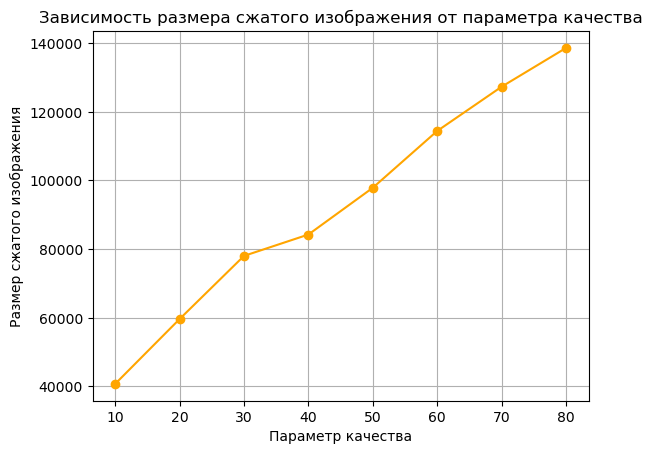

In [33]:
import numpy as np
import struct
import os
from PIL import Image
import matplotlib.pyplot as plt

def load_raw(input_path):
    with open(input_path, 'rb') as f:
        header = f.read(12)
        width, height, channels = struct.unpack('<IIB', header[:9])
        data = f.read()
        arr = np.frombuffer(data, dtype=np.uint8)
        return arr.reshape((height, width, channels)) if channels == 3 else arr.reshape((height, width))

def save_raw(output_path, img_array):
    if img_array.ndim == 2: h, w, channels = *img_array.shape, 1
    else: h, w, channels = img_array.shape
    header = struct.pack('<IIB', w, h, channels) + b'\x00' * 3
    with open(output_path, 'wb') as f:
        f.write(header)
        f.write(img_array.tobytes())

# Базовые преобразования
def rgb_to_ycbcr(rgb):
    transform_matrix = np.array([[0.299, 0.587, 0.114], [-0.168736, -0.331264, 0.5], [0.5, -0.418688, -0.081312]], dtype=np.float32)
    offsets = np.array([0, 128, 128], dtype=np.float32)
    ycbcr = np.dot(rgb.astype(np.float32), transform_matrix.T) + offsets
    return np.clip(ycbcr, 0, 255).round().astype(np.uint8)

def ycbcr_to_rgb(ycbcr):
    transform_matrix = np.array([[1, 0, 1.402], [1, -0.34414, -0.714136], [1, 1.772, 0]], dtype=np.float32)
    offsets = np.array([0, -128, -128], dtype=np.float32)
    rgb = np.dot((ycbcr.astype(np.float32) + offsets), transform_matrix.T)
    return np.clip(rgb, 0, 255).round().astype(np.uint8)

def split_into_blocks(image, block_size=8):
    h, w = image.shape[:2]
    is_color = len(image.shape) == 3
    channels = image.shape[2] if is_color else 1
    pad_h = (block_size - h % block_size) % block_size
    pad_w = (block_size - w % block_size) % block_size
    h_p, w_p = h + pad_h, w + pad_w
    if is_color:
        padded = np.full((h_p, w_p, channels), 255, dtype=image.dtype)
        padded[:h, :w, :] = image
    else:
        padded = np.full((h_p, w_p), 255, dtype=image.dtype)
        padded[:h, :w] = image
    blocks = []
    for i in range(0, h_p, block_size):
        for j in range(0, w_p, block_size):
            blocks.append(padded[i:i+block_size, j:j+block_size])
    return blocks

def merge_blocks(blocks, original_shape, block_size=8):
    h_orig, w_orig = original_shape[:2]
    is_color = len(original_shape) == 3
    channels = original_shape[2] if is_color else 1
    pad_h = (block_size - h_orig % block_size) % block_size
    pad_w = (block_size - w_orig % block_size) % block_size
    h_p, w_p = h_orig + pad_h, w_orig + pad_w
    reconstructed = np.zeros((h_p, w_p, channels) if is_color else (h_p, w_p), dtype=blocks[0].dtype)
    idx = 0
    for i in range(0, h_p, block_size):
        for j in range(0, w_p, block_size):
            reconstructed[i:i+block_size, j:j+block_size] = blocks[idx]
            idx += 1
    return reconstructed[:h_orig, :w_orig]

def get_dct_matrix(size):
    n, k = np.arange(size), np.arange(size)
    cos_vals = np.cos(np.pi / size * (n + 0.5) * k[:, np.newaxis])
    alpha = np.where(k == 0, np.sqrt(1.0 / size), np.sqrt(2.0 / size))
    return cos_vals * alpha[:, np.newaxis]

def dct_2d_matrix(block): 
    return get_dct_matrix(block.shape[0]) @ block @ get_dct_matrix(block.shape[1]).T

def idct_2d_matrix(dct_block): 
    return get_dct_matrix(dct_block.shape[0]).T @ dct_block @ get_dct_matrix(dct_block.shape[1])

def quantize_dct(dct_coeffs, quant_matrix): 
    return np.round(dct_coeffs / quant_matrix).astype(np.int32)

def normalize_dct(quant_coeffs, quant_matrix): 
    return quant_coeffs.astype(np.float64) * quant_matrix

def zigzag_scan(matrix):
    n, m = matrix.shape
    result = []
    for s in range(n + m - 1):
        i_start, i_end = max(0, s - m + 1), min(n - 1, s)
        if s % 2 == 1:
            for i in range(i_start, i_end + 1): result.append(matrix[i, s - i])
        else:
            for i in range(i_end, i_start - 1, -1): result.append(matrix[i, s - i])
    return result

def inverse_zigzag(vector, shape):
    matrix = np.zeros(shape, dtype=np.int32)
    idx = 0
    n, m = shape
    for s in range(n + m - 1):
        i_start, i_end = max(0, s - m + 1), min(n - 1, s)
        if s % 2 == 1:
            for i in range(i_start, i_end + 1): 
                matrix[i, s - i] = vector[idx]
                idx += 1
        else:
            for i in range(i_end, i_start - 1, -1): 
                matrix[i, s - i] = vector[idx]
                idx += 1
    return matrix

# Таблицы квантования
Q_LUM_BASE = np.array([
    16, 11, 10, 16, 24, 40, 51, 61, 12, 12, 14, 19, 26, 58, 60, 55,
    14, 13, 16, 24, 40, 57, 69, 56, 14, 17, 22, 29, 51, 87, 80, 62,
    18, 22, 37, 56, 68, 109, 103, 77, 24, 35, 55, 64, 81, 104, 113, 92,
    49, 64, 78, 87, 103, 121, 120, 101, 72, 92, 95, 98, 112, 100, 103, 99
], dtype=np.float64).reshape(8, 8)

Q_CHROM_BASE = np.array([
    17, 18, 24, 47, 99, 99, 99, 99, 18, 21, 26, 66, 99, 99, 99, 99,
    24, 26, 56, 99, 99, 99, 99, 99, 47, 66, 99, 99, 99, 99, 99, 99,
    99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99,
    99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99
], dtype=np.float64).reshape(8, 8)

def scale_quantization_tables(quality):
    quality = max(1, min(100, quality))
    s = 5000.0 / quality if quality < 50 else 200.0 - 2.0 * quality
    q_y = np.round((Q_LUM_BASE * s) / 100.0)
    q_c = np.round((Q_CHROM_BASE * s) / 100.0)
    return np.clip(q_y, 1, 255).astype(np.uint8), np.clip(q_c, 1, 255).astype(np.uint8)

# Функции для кодирования
def differential_encode_dc(dc_coefficients):
    if not dc_coefficients:
        return []
    diff_codes = []
    prev_dc = 0
    for dc in dc_coefficients:
        diff = dc - prev_dc
        diff_codes.append(diff)
        prev_dc = dc
    return diff_codes

def differential_decode_dc(diff_codes):
    if not diff_codes:
        return []
    dc_coefficients = []
    prev_dc = 0
    for diff in diff_codes:
        dc = prev_dc + diff
        dc_coefficients.append(dc)
        prev_dc = dc
    return dc_coefficients

def rle_encode_ac(ac_coefficients):
    rle_codes = []
    zero_count = 0
    for coeff in ac_coefficients:
        if coeff == 0:
            zero_count += 1
        else:
            while zero_count >= 16:
                rle_codes.append((15, 0))
                zero_count -= 16
            rle_codes.append((zero_count, coeff))
            zero_count = 0
    rle_codes.append((0, 0))
    return rle_codes

def get_category(value):
    value = int(value)
    if value == 0:
        return 0
    return abs(value).bit_length()

def encode_value(value, category):
    value = int(value)
    if category == 0:
        return 0
    if value > 0:
        return value
    else:
        return (1 << category) - 1 - abs(value)

def decode_value(encoded_value, category):
    encoded_value = int(encoded_value)
    if category == 0:
        return 0
    if encoded_value & (1 << (category - 1)):
        return encoded_value
    else:
        return encoded_value - ((1 << category) - 1)

# Таблицы Хаффмана
def build_canonical_huffman_table(symbols_with_lengths):
    sorted_symbols = sorted(symbols_with_lengths, key=lambda x: (x[1], x[0]))
    
    table = {}
    code = 0
    prev_length = 0
    
    for symbol, length in sorted_symbols:
        if length > prev_length:
            code <<= (length - prev_length)
            prev_length = length
        
        table[symbol] = (code, length)
        code += 1
    
    return table

def build_huffman_tree(table):
    tree = {}
    for symbol, (code, length) in table.items():
        tree[(code, length)] = symbol
    return tree

# Оптимальные длины кодов для AC коэффициентов
def get_ac_code_lengths():
    lengths = []
    
    # EOB - самый частый, самый короткий код
    lengths.append((0x00, 2))
    
    # ZRL - редкий, длинный код
    lengths.append((0xF0, 12))
    
    # Генерируем для всех комбинаций run (0-15) и category (1-10)
    # Чем меньше run и category, тем короче код
    for run in range(16):
        for cat in range(1, 11):
            symbol = (run << 4) | cat
            if run == 0 and cat <= 5:
                length = 3 + cat
            elif run <= 1 and cat <= 3:
                length = 5 + run + cat
            elif run <= 3 and cat <= 4:
                length = 7 + (run // 2) + (cat // 2)
            else:
                length = 10 + (run // 4) + (cat // 3)
            length = min(length, 15)
            lengths.append((symbol, length))
    
    return lengths

# Строим таблицы
DC_CODE_LENGTHS = [(i, 2 if i == 0 else 3 + (i - 1) // 2) for i in range(12)]
DC_LUM_TAB = build_canonical_huffman_table(DC_CODE_LENGTHS)
DC_CHROM_TAB = DC_LUM_TAB.copy()
AC_LUM_TAB = build_canonical_huffman_table(get_ac_code_lengths())
AC_CHROM_TAB = AC_LUM_TAB.copy()

# Строим деревья
DC_LUM_TREE = build_huffman_tree(DC_LUM_TAB)
DC_CHROM_TREE = build_huffman_tree(DC_CHROM_TAB)
AC_LUM_TREE = build_huffman_tree(AC_LUM_TAB)
AC_CHROM_TREE = build_huffman_tree(AC_CHROM_TAB)

class BitWriter:
    def __init__(self): 
        self.buffer = 0
        self.bit_count = 0
        self.bytes = bytearray()
    
    def write(self, bits, length):
        if length == 0: return
        self.buffer = (self.buffer << length) | bits
        self.bit_count += length
        while self.bit_count >= 8:
            self.bit_count -= 8
            byte = (self.buffer >> self.bit_count) & 0xFF
            self.bytes.append(byte)
            if byte == 0xFF:
                self.bytes.append(0x00)
    
    def flush(self):
        if self.bit_count > 0:
            byte = (self.buffer << (8 - self.bit_count)) & 0xFF
            self.bytes.append(byte)
            if byte == 0xFF:
                self.bytes.append(0x00)
        return bytes(self.bytes)

class BitReader:
    def __init__(self, data): 
        self.data = data
        self.pos = 0
        self.buffer = 0
        self.bit_count = 0
        self.raw_pos = 0
    
    def read_byte_raw(self):
        if self.raw_pos >= len(self.data):
            return None
        byte = self.data[self.raw_pos]
        self.raw_pos += 1
        return byte
    
    def read_byte_with_stuffing(self):
        if self.pos >= len(self.data):
            return None
        byte = self.data[self.pos]
        self.pos += 1
        if byte == 0xFF and self.pos < len(self.data) and self.data[self.pos] == 0x00:
            self.pos += 1
        return byte
    
    def read(self, length):
        while self.bit_count < length:
            byte = self.read_byte_with_stuffing()
            self.buffer = (self.buffer << 8) | byte
            self.bit_count += 8
        
        bits = (self.buffer >> (self.bit_count - length)) & ((1 << length) - 1)
        self.bit_count -= length
        return bits

# Декодер с использованием дерева Хаффмана
def decode_huffman_symbol(reader, tree, max_length=16):
    bits = 0
    for length in range(1, max_length + 1):
        bit = reader.read(1)
        bits = (bits << 1) | bit
        if (bits, length) in tree:
            return tree[(bits, length)]
    return None

# Компрессор
def compress_image(img_array, quality=75):
    h, w = img_array.shape[:2]
    is_color = len(img_array.shape) == 3
    q_y, q_c = scale_quantization_tables(quality)

    if is_color:
        ycbcr = rgb_to_ycbcr(img_array)
        planes = [ycbcr[:,:,i] for i in range(3)]
    else:
        planes = [img_array]
    
    writer = BitWriter()
    block_counts = []
    
    for p_idx, plane in enumerate(planes):
        is_lum = (p_idx == 0)
        q_table = q_y if is_lum else q_c
        blocks = split_into_blocks(plane, 8)
        block_counts.append(len(blocks))
        
        dc_tab = DC_LUM_TAB if is_lum else DC_CHROM_TAB
        ac_tab = AC_LUM_TAB if is_lum else AC_CHROM_TAB
        
        all_dc = []
        all_ac = []
        
        for block in blocks:
            dct = dct_2d_matrix(block.astype(np.float64) - 128)
            q_blk = quantize_dct(dct, q_table)
            zz = zigzag_scan(q_blk)
            all_dc.append(zz[0])
            all_ac.append(zz[1:])
        
        # DC кодирование
        diff_dc = differential_encode_dc(all_dc)
        for diff in diff_dc:
            cat = get_category(diff)
            code, length = dc_tab[cat]
            writer.write(code, length)
            if cat > 0:
                amp = encode_value(diff, cat)
                writer.write(amp, cat)
        
        # AC кодирование
        for ac_coeffs in all_ac:
            rle_codes = rle_encode_ac(ac_coeffs)
            for run, value in rle_codes:
                cat = get_category(value)
                symbol = (run << 4) | cat
                
                code, length = ac_tab[symbol]
                writer.write(code, length)
                
                if cat > 0:
                    amp = encode_value(value, cat)
                    writer.write(amp, cat)
    
    return writer.flush(), block_counts, q_y, q_c

# Декомпрессор
def decompress_image(bitstream, width, height, q_y, q_c, block_counts,
                     DC_LUM_TREE, DC_CHROM_TREE, AC_LUM_TREE, AC_CHROM_TREE):
    reader = BitReader(bitstream)
    is_color = len(block_counts) == 3
    planes = []

    for p_idx, count in enumerate(block_counts):
        is_lum = (p_idx == 0)
        q_table = q_y if is_lum else q_c
        dc_tree = DC_LUM_TREE if is_lum else DC_CHROM_TREE
        ac_tree = AC_LUM_TREE if is_lum else AC_CHROM_TREE
        
        # Декодируем DC
        dc_diffs = []
        for i in range(count):
            symbol = decode_huffman_symbol(reader, dc_tree, 12)
            
            cat = symbol
            if cat > 0:
                extra = reader.read(cat)
                val = decode_value(extra, cat)
            else:
                val = 0
            dc_diffs.append(val)
        
        dc_coeffs = differential_decode_dc(dc_diffs)
        
        # Декодируем AC
        blocks = []
        for block_idx in range(count):
            coeffs = [dc_coeffs[block_idx]]
            
            while len(coeffs) < 64:
                symbol = decode_huffman_symbol(reader, ac_tree, 16)
                if symbol is None:
                    break
                
                run = symbol >> 4
                cat = symbol & 0x0F
                
                if run == 0 and cat == 0:  # EOB
                    break
                
                if run == 15 and cat == 0:  # ZRL
                    coeffs.extend([0] * 16)
                    continue
                
                if cat > 0:
                    extra = reader.read(cat)
                    val = decode_value(extra, cat)
                else:
                    val = 0
                
                coeffs.extend([0] * run)
                coeffs.append(val)
            
            while len(coeffs) < 64:
                coeffs.append(0)
            
            q_blk = inverse_zigzag(np.array(coeffs[:64]), (8, 8))
            dct_blk = normalize_dct(q_blk.astype(np.float64), q_table)
            recon = idct_2d_matrix(dct_blk) + 128
            blocks.append(np.clip(recon, 0, 255).astype(np.uint8))
        
        plane = merge_blocks(blocks, (height, width), 8)
        planes.append(plane)
    
    if is_color:
        ycbcr = np.stack(planes, axis=-1)
        return ycbcr_to_rgb(ycbcr)
    else:
        return planes[0]

# Сохранение/загрузка
def save_huffman_table(f, table, table_id):
    f.write(struct.pack('B', table_id))
    f.write(struct.pack('<H', len(table)))
    for symbol, (code, length) in table.items():
        f.write(struct.pack('<H', symbol))
        f.write(struct.pack('<H', code))
        f.write(struct.pack('B', length))

def load_huffman_table(f):
    table_id = struct.unpack('B', f.read(1))[0]
    size = struct.unpack('<H', f.read(2))[0]
    table = {}
    for _ in range(size):
        symbol = struct.unpack('<H', f.read(2))[0]
        code = struct.unpack('<H', f.read(2))[0]
        length = struct.unpack('B', f.read(1))[0]
        table[symbol] = (code, length)
    return table_id, table

def compress_raw_to_file(raw_path, jpc_path, quality=75):
    img_array = load_raw(raw_path)
    bitstream, block_counts, q_y, q_c = compress_image(img_array, quality)
    
    with open(jpc_path, 'wb') as f:
        f.write(struct.pack('<II', img_array.shape[1], img_array.shape[0]))
        f.write(struct.pack('B', quality))
        f.write(struct.pack('B', 3 if len(img_array.shape) == 3 else 1))
        f.write(struct.pack('B', len(block_counts)))
        f.write(q_y.tobytes())
        if len(img_array.shape) == 3:
            f.write(q_c.tobytes())
        
        save_huffman_table(f, DC_LUM_TAB, 0)
        save_huffman_table(f, DC_CHROM_TAB, 1)
        save_huffman_table(f, AC_LUM_TAB, 2)
        save_huffman_table(f, AC_CHROM_TAB, 3)
        
        for bc in block_counts:
            f.write(struct.pack('<I', bc))
        f.write(struct.pack('<I', len(bitstream)))
        f.write(bitstream)

def decompress_file_to_raw(jpc_path, raw_path):
    with open(jpc_path, 'rb') as f:
        width = struct.unpack('<I', f.read(4))[0]
        height = struct.unpack('<I', f.read(4))[0]
        quality = struct.unpack('B', f.read(1))[0]
        channels = struct.unpack('B', f.read(1))[0]
        num_planes = struct.unpack('B', f.read(1))[0]
        
        q_y = np.frombuffer(f.read(64), dtype=np.uint8).reshape(8, 8)
        q_c = np.zeros((8, 8), dtype=np.uint8)
        if channels == 3:
            q_c = np.frombuffer(f.read(64), dtype=np.uint8).reshape(8, 8)
        
        tables = {}
        for _ in range(4):
            table_id, table = load_huffman_table(f)
            tables[table_id] = table
        
        DC_LUM_TAB_loaded = tables[0]
        DC_CHROM_TAB_loaded = tables[1]
        AC_LUM_TAB_loaded = tables[2]
        AC_CHROM_TAB_loaded = tables[3]
        
        DC_LUM_TREE_LOADED = build_huffman_tree(DC_LUM_TAB_loaded)
        DC_CHROM_TREE_LOADED = build_huffman_tree(DC_CHROM_TAB_loaded)
        AC_LUM_TREE_LOADED = build_huffman_tree(AC_LUM_TAB_loaded)
        AC_CHROM_TREE_LOADED = build_huffman_tree(AC_CHROM_TAB_loaded)
        
        block_counts = [struct.unpack('<I', f.read(4))[0] for _ in range(num_planes)]
        bs_len = struct.unpack('<I', f.read(4))[0]
        bitstream = f.read(bs_len)
    
    img_array = decompress_image(bitstream, width, height, q_y, q_c, block_counts,
                                  DC_LUM_TREE_LOADED, DC_CHROM_TREE_LOADED,
                                  AC_LUM_TREE_LOADED, AC_CHROM_TREE_LOADED)
    save_raw(raw_path, img_array)
    return img_array



raw_path = "C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 2/test_files/people_bw_round/people_bw_round.raw"

qualities = [i for i in range(10, 81, 10)]
sizes = []
orig_size = os.path.getsize(raw_path)

for i in qualities:
    comp = f"C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 2/test_files/people_bw_round/people_bw_round_comp_{i}.jpc"
    decomp = f"C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 2/test_files/people_bw_round/people_bw_round_decomp_{i}.raw"
    decomp_png = f"C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 2/test_files/people_bw_round/people_bw_round_decomp_{i}.png"

    compress_raw_to_file(raw_path, comp, quality=i)
    comp_size = os.path.getsize(comp)
    sizes.append(comp_size)

    recon = decompress_file_to_raw(comp, decomp)

    Image.fromarray(recon).save(decomp_png)
    recon_size = os.path.getsize(decomp_png)

    print(f"Качество {i}")
    print(f"Исходный: {orig_size} байт | Сжатый: {comp_size} байт | Восстановленный: {recon_size} байт | Степень: {orig_size/comp_size:.2f}")


plt.plot(qualities, sizes, marker='o',color = 'orange')
plt.xlabel('Параметр качества')
plt.ylabel('Размер сжатого изображения')
plt.title('Зависимость размера сжатого изображения от параметра качества')
plt.grid(True)
plt.show()
